# Signatures of the SMC's influence on the LMC's stellar halo

### Hayden Foote and Himansh Rathore (University of Arizona)

This notebook plots radial velocity maps and tangential velocity dispersion maps of particles around the LMC, similar to Fig. 17 of Foote+26. Uses Himansh Rathore's lmcsmcmw09 MEGHA simulation, which is a three-body simulation of the LMC-SMC-MW interaction. 

The goal is to identify potentially obsevable signatures of the SMC's influence on the LMC stellar halo, including the reflex motion of the LMC disk, and SMC dynamical friction wake. A key difference from Foote+26 is that this simulation includes the MW, and therefore we will need to disentangle the SMC's effects from those of the MW's tides.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from snapanalysis.snap import snapshot # snapanalysis is available from https://github.com/hfoote/snapAnalysis
from snapanalysis import utils
from astropy import units as u
import healpy as hp

We will use the present-day snapshot of lmcsmcmw09, stored on the University of Arizona's HPC facilities.

In [2]:
# paths
simdir = '/xdisk/gbesla/group/lmcsmcmw09/' # snapshots stored here
comdir = '/xdisk/gbesla/group/lmcsmcmw09/com/' # centers 
rotdir = '/xdisk/gbesla/group/lmcsmcmw09/angular_momentum/' # rotation matrices

# particle ID ranges for each galaxy
min_lmc_id = 1
max_lmc_id = 11600001
min_smc_id = 11600002
max_smc_id = 13144002
min_mw_id = 13144003
max_mw_id = 44144003

# present-day snapshot
pres_idx = 401

We have also precomputed the centers of mass of each galaxy as a function of time, as well as the rotation matrices necessary to transform between the box frame and the LMC's disk plane.

In [3]:
# COMs
lmc_c = np.load(comdir+"LMC_com_pos.npy")[:,pres_idx]*u.kpc
lmc_v = np.load(comdir+"LMC_com_vel.npy")[:,pres_idx]*u.km/u.s
smc_c = np.load(comdir+"SMC_com_pos.npy")[:,pres_idx]*u.kpc
smc_v = np.load(comdir+"SMC_com_vel.npy")[:,pres_idx]*u.km/u.s
mw_c = np.load(comdir+"MW_com_pos.npy")[:,pres_idx]*u.kpc
mw_v = np.load(comdir+"MW_com_vel.npy")[:,pres_idx]*u.km/u.s

# Rotation to LMC disk plane
rot = np.load(rotdir+"LMC_align_matrix.npy")[:,:,pres_idx]

In [4]:
# SMC orbit with respect to LMC
smc_orb = np.load(comdir+"SMC_com_pos.npy") - np.load(comdir+"LMC_com_pos.npy")
# in LMC disk frame
smc_orb_lmc_frame = np.matmul(rot, smc_orb).T
# in spherical coordinates
smc_orb_sph = utils.cartesian_to_spherical(smc_orb_lmc_frame)[:pres_idx]

## Helper and plotting functions

In [5]:
def select_shell(r, center, thick=5.):
    '''returns a mask for particles within a spherical shell.

    r : particle radial positions
    center : center of shell
    thick : thickness of shell
    '''
    upr = center + thick/2.
    lwr = center - thick/2.

    return (r >= lwr) & (r < upr)

def mollweide_projection(theta, phi, title, bmin=None, bmax=None, nside=50, smooth=1., q=[0], stat='mean', unit="", overdensity=False, **kwargs):

	"""
	From Nico Garavito-Camargo,
	Makes mollweide plot using healpix

	Parameters:
	----------- 
	l : numpy.array in degrees 
	b : numpy.array in degrees [-90, 90]
	bmin : colorbar minimum
	bmax : colorbar maximum
	nside : number of pixels per angular dimension
	smooth : smoothing length in deg
	q : weighting array
	stat : statistic used to compute the weights with q. 'mean' uses the mean of q in each pixel, 
		   'std' uses standard deviation of q in each pixel.

	"""

	# array of indices that assigns each particle to a pixel
	pix_indices = hp.ang2pix(nside, theta, phi)
	npix = hp.nside2npix(nside)
	# get an array of the unique pixels and the number of particles in each
	idx, counts = np.unique(pix_indices, return_counts=True)
	degsq = hp.nside2pixarea(nside, degrees=True) # area of each pixel
	# filling the full-sky map
	hpx_map = np.zeros(npix, dtype=float) # empty map
	if q[0] != 0 :    
		counts = np.zeros_like(idx, dtype=float) # zero the counts

		for k, i in enumerate(idx): # go through each pixel
			pix_ids = np.where(pix_indices==i)[0] # find out which particles are in that pixel
			if stat == 'mean':
				counts[k] = np.mean(q[pix_ids]) # weight the counts by q
			elif stat == 'std':
				counts[k] = np.std(q[pix_ids]) # weight the counts by q
			else:
				raise ValueError("Invalid statistic specified for weighting")
		hpx_map[idx] = counts
	else :
		hpx_map[idx] = counts/degsq
	
	map_smooth = hp.smoothing(hpx_map, fwhm=smooth*np.pi/180)
	if overdensity:
		map_smooth = map_smooth/np.mean(map_smooth) - 1.

	if 'figname' in kwargs.keys():
		fig, ax = plt.subplots(1, 1, figsize=(12, 5))
		
		if 'cmap' in kwargs.keys():
			cmap = kwargs['cmap']
		else:
			cmap = 'viridis'

		projview(
			map_smooth,
			coord=["G"],
			graticule=True,
			graticule_labels=True,
			rot=(0, 0, 0),
			unit=unit,
			xlabel="Galactic Longitude (l) ",
			ylabel="Galactic Latitude (b)",
			cb_orientation="horizontal",
			min=bmin,
			max=bmax,
			cmap=cmap,
			latitude_grid_spacing=45,
			projection_type="mollweide",
			title=title,
			)
	
	if 'l2' in kwargs.keys() and 'b2' in kwargs.keys():
		# note newprojplot expects coordinates in radians: polar angle (0, pi) from +z, azimuthal angle (-pi, pi) from middle of projection (+x):
		polar = np.radians(90-kwargs['b2']) 
		azi = np.radians(kwargs['l2'])
		azi[azi>np.pi] -= 2.*np.pi # put into -pi, pi
		newprojplot(polar, azi, color="k")
	
	if 'l3' in kwargs.keys() and 'b3' in kwargs.keys():
		# note newprojplot expects coordinates in radians: polar angle (0, pi) from +z, azimuthal angle (-pi, pi) from middle of projection (+x):
		polar = np.radians(90-kwargs['b3']) 
		azi = np.radians(kwargs['l3'])
		azi[azi>np.pi] -= 2.*np.pi # put into -pi, pi
		newprojplot(polar, azi, color="k", linestyle='dotted')
	
	if 'figname' in kwargs.keys():
		print("* Saving figure in ", kwargs['figname'])
		plt.savefig(kwargs['figname'], bbox_inches='tight')
		plt.close()

		if 'saveMap' in kwargs.keys():
			np.save(kwargs['figname'].split('.')[0]+'.npy', map_smooth)
			
	#return 0
	plt.close()
	if 'returnMap' in kwargs.keys(): 
		return map_smooth

In [6]:
# make vr and vsigma maps
def make_projections(particles, save_as, smooth=30., inner=5., mid=10., mid_out=20., out=30., thick=1., v_lim=20., sig_lim=0.5, weight=1.0):
    """
    Makes mollweide projections in shells at three different distances. 

    Parameters
    ----------
    particles: snapanalysis.snap.snapshot
        Simulation particles to make plots with. Should already be selected/centered/rotated. 
    save_as: str
        filename to save the plot under
    inner: float
        Radius of inner shell
    mid: float
        Radius of mid shell
    out: float
        Radius of outer shell
    thick: float
        Thickness of shell
    v_lim: float
        Limit for radial velocity colorbar
    sig_lim: float
        Limit for tangential disperion colorbar
    weight: float
        Factor that weights the derived velocity maps as a very rough compensation for MW mass differences
    """

    pos = particles.data_fields['Coordinates']
    vel = particles.data_fields['Velocities']
    pos_spherical = utils.cartesian_to_spherical(pos)
    vel_spherical = utils.vector_cartesian_to_spherical(pos, vel)
    
    r = pos_spherical[:,0]
    theta = pos_spherical[:,1]
    phi = pos_spherical[:,2]
    
    v_r = vel_spherical[:,0]
    v_theta = vel_spherical[:,1]
    v_phi = vel_spherical[:,2]
    
    shell_in = select_shell(r, inner, thick=1.)
    shell_mid = select_shell(r, mid, thick=1.)
    shell_mid_out = select_shell(r, mid_out, thick=1.)
    shell_out = select_shell(r, out, thick=1.)
    
    vr_in = mollweide_projection(theta[shell_in], phi[shell_in], '', q=v_r[shell_in], stat='mean', returnMap=1, smooth=smooth)*weight
    sigmatheta_in = mollweide_projection(theta[shell_in], phi[shell_in], '', q=v_theta[shell_in], stat='std', returnMap=1, smooth=smooth)
    sigmaphi_in = mollweide_projection(theta[shell_in], phi[shell_in], '', q=v_phi[shell_in], stat='std', returnMap=1, smooth=smooth)
    sigmatan_in = np.sqrt(sigmatheta_in**2 + sigmaphi_in**2)*weight
    
    vr_mid = mollweide_projection(theta[shell_mid], phi[shell_mid], '', q=v_r[shell_mid], stat='mean', returnMap=1, smooth=smooth)*weight
    sigmatheta_mid = mollweide_projection(theta[shell_mid], phi[shell_mid], '', q=v_theta[shell_mid], stat='std', returnMap=1, smooth=smooth)
    sigmaphi_mid = mollweide_projection(theta[shell_mid], phi[shell_mid], '', q=v_phi[shell_mid], stat='std', returnMap=1, smooth=smooth)
    sigmatan_mid = np.sqrt(sigmatheta_mid**2 + sigmaphi_mid**2)*weight

    vr_mid_out = mollweide_projection(theta[shell_mid_out], phi[shell_mid_out], '', q=v_r[shell_mid_out], stat='mean', returnMap=1, smooth=smooth)*weight
    sigmatheta_mid_out = mollweide_projection(theta[shell_mid_out], phi[shell_mid_out], '', q=v_theta[shell_mid_out], stat='std', returnMap=1, smooth=smooth)
    sigmaphi_mid_out = mollweide_projection(theta[shell_mid_out], phi[shell_mid_out], '', q=v_phi[shell_mid_out], stat='std', returnMap=1, smooth=smooth)
    sigmatan_mid_out = np.sqrt(sigmatheta_mid_out**2 + sigmaphi_mid_out**2)*weight
    
    vr_out = mollweide_projection(theta[shell_out], phi[shell_out], '', q=v_r[shell_out], stat='mean', returnMap=1, smooth=smooth)*weight
    sigmatheta_out = mollweide_projection(theta[shell_out], phi[shell_out], '', q=v_theta[shell_out], stat='std', returnMap=1, smooth=smooth)
    sigmaphi_out = mollweide_projection(theta[shell_out], phi[shell_out], '', q=v_phi[shell_out], stat='std', returnMap=1, smooth=smooth)
    sigmatan_out = np.sqrt(sigmatheta_out**2 + sigmaphi_out**2)*weight

    cmap_vr = 'RdBu_r'
    cmap_sig = 'PuOr_r'
    vmin_v = -v_lim
    vmax_v = v_lim
    vmin_sigma = -sig_lim
    vmax_sigma = sig_lim
    plt.rcParams['font.size'] = '12'
    fig, axes = plt.subplots(4, 2, figsize=(8, 10), dpi=300)
    
    plt.axes(axes[0, 0])
    hp.newvisufunc.projview(
    	vr_in,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	ylabel=f"{inner} kpc\n$\\theta$",
    	cmap=cmap_vr,
    	min=vmin_v, 
    	max=vmax_v,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='$v_r$',
    	sub=421,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[0, 1])
    hp.newvisufunc.projview(
    	sigmatan_in/np.mean(sigmatan_in)-1,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	cmap=cmap_sig,
    	min=vmin_sigma, 
    	max=vmax_sigma,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='$\\sigma_{tan}$',
    	sub=422,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[1, 0])
    im1 = hp.newvisufunc.projview(
    	vr_mid,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	ylabel=f"{mid} kpc\n$\\theta$",
    	cmap=cmap_vr,
    	min=vmin_v, 
    	max=vmax_v,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=423,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[1, 1])
    im2 = hp.newvisufunc.projview(
    	sigmatan_mid/np.mean(sigmatan_mid)-1,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	cmap=cmap_sig,
    	min=vmin_sigma, 
    	max=vmax_sigma,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=424,
    	cbar=False,
    	hold=True
    	)

    plt.axes(axes[2, 0])
    im1 = hp.newvisufunc.projview(
    	vr_mid_out,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	ylabel=f"{mid_out} kpc\n$\\theta$",
    	cmap=cmap_vr,
    	min=vmin_v, 
    	max=vmax_v,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=425,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[2, 1])
    im2 = hp.newvisufunc.projview(
    	sigmatan_mid_out/np.mean(sigmatan_mid_out)-1,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	cmap=cmap_sig,
    	min=vmin_sigma, 
    	max=vmax_sigma,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=426,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[3, 0])
    im1 = hp.newvisufunc.projview(
    	vr_out,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	xlabel="$\phi$",
    	ylabel=f"{out} kpc\n$\\theta$",
    	cmap=cmap_vr,
    	min=vmin_v, 
    	max=vmax_v,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=427,
    	cbar=False,
        unit='$v_r$ [km/s]',
    	hold=True
    	)
    
    plt.axes(axes[3, 1])
    im2 = hp.newvisufunc.projview(
    	sigmatan_out/np.mean(sigmatan_out)-1,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
    	xlabel="$\phi$",
    	cmap=cmap_sig,
    	min=vmin_sigma, 
    	max=vmax_sigma,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=428,
    	cbar=False,
        unit='$\\sigma_r / \\bar{\\sigma}_r - 1$',
    	hold=True
    	)

    # plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, hspace=0.01)
    cbar1_ax = fig.add_axes([0.03, 0.05, 0.43, 0.03])
    cbar2_ax = fig.add_axes([0.55, 0.05, 0.43, 0.03])
    plt.colorbar(im1, cax=cbar1_ax, label='$v_r$ [km s$^{-1}$]', orientation='horizontal')
    plt.colorbar(im2, cax=cbar2_ax, label='$\\sigma_{tan} / \\bar{\\sigma}_{tan} - 1$', orientation='horizontal')
    plt.savefig(save_as, bbox_inches='tight')
    plt.show()

In [7]:
# density map function for SMC debris
def make_density_maps(particles, save_as, smooth=30., inner=5., mid=10., mid_out=20., out=30., thick=1., weight=1.0):
    """
    Makes mollweide projections in shells at three different distances. 

    Parameters
    ----------
    particles: snapanalysis.snap.snapshot
        Simulation particles to make plots with. Should already be selected/centered/rotated. 
    save_as: str
        filename to save the plot under
    inner: float
        Radius of inner shell
    mid: float
        Radius of mid shell
    out: float
        Radius of outer shell
    thick: float
        Thickness of shell
    v_lim: float
        Limit for radial velocity colorbar
    sig_lim: float
        Limit for tangential disperion colorbar
    weight: float
        Factor that weights the derived velocity maps as a very rough compensation for MW mass differences
    """

    pos = particles.data_fields['Coordinates']
    pos_spherical = utils.cartesian_to_spherical(pos)
    
    r = pos_spherical[:,0]
    theta = pos_spherical[:,1]
    phi = pos_spherical[:,2]
    
    shell_in = select_shell(r, inner, thick=1.)
    shell_mid = select_shell(r, mid, thick=1.)
    shell_mid_out = select_shell(r, mid_out, thick=1.)
    shell_out = select_shell(r, out, thick=1.)
    
    rho_in = mollweide_projection(theta[shell_in], phi[shell_in], '', stat='mean', returnMap=1, smooth=smooth)*weight
    rho_mid = mollweide_projection(theta[shell_mid], phi[shell_mid], '', stat='mean', returnMap=1, smooth=smooth)*weight
    rho_mid_out = mollweide_projection(theta[shell_mid_out], phi[shell_mid_out], '', stat='mean', returnMap=1, smooth=smooth)*weight
    rho_out = mollweide_projection(theta[shell_out], phi[shell_out], '', stat='mean', returnMap=1, smooth=smooth)*weight
    
    cmap_rho = 'viridis'
    plt.rcParams['font.size'] = '12'
    fig, axes = plt.subplots(4, 1, figsize=(8, 8), dpi=300)
    
    plt.axes(axes[0])
    hp.newvisufunc.projview(
    	rho_in,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
        min=0.,
        max=50.,
    	ylabel=f"{inner} kpc\n$\\theta$",
    	cmap=cmap_rho,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='$density$',
    	sub=411,
    	cbar=False,
    	hold=True
    	)
    hp.newvisufunc.newprojplot(smc_orb_sph[:,1], smc_orb_sph[:,2], color="white")
    hp.newvisufunc.newprojplot(smc_orb_sph[-1,1], smc_orb_sph[-1,2], color='white', marker='o')
    
    plt.axes(axes[1])
    hp.newvisufunc.projview(
    	rho_mid,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
        min=0.,
        max=50.,
    	ylabel=f"{mid} kpc\n$\\theta$",
    	cmap=cmap_rho,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	sub=412,
    	cbar=False,
    	hold=True
    	)

    plt.axes(axes[2])
    hp.newvisufunc.projview(
    	rho_mid_out,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
        min=0.,
        max=50.,
    	ylabel=f"{mid_out} kpc\n$\\theta$",
    	cmap=cmap_rho,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	sub=413,
    	cbar=False,
    	hold=True
    	)
    
    plt.axes(axes[3])
    im1 = hp.newvisufunc.projview(
    	rho_out,
    	coord=["G"],
    	graticule=True,
    	graticule_labels=True,
    	rot=(0, 0, 0),
        min=0.,
        max=50.,
    	ylabel=f"{out} kpc\n$\\theta$",
    	cmap=cmap_rho,
    	latitude_grid_spacing=45,
    	projection_type="mollweide",
    	title='',
    	sub=414,
    	cbar=False,
    	hold=True
    	)

    plt.subplots_adjust(bottom=0.1, hspace=0.01)
    cbar1_ax = fig.add_axes([0.03, 0.05, 0.9, 0.03])
    plt.colorbar(im1, cax=cbar1_ax, label='$density [deg$^2$]$', orientation='horizontal')
    # plt.legend()
    plt.savefig(save_as, bbox_inches='tight')
    plt.show()

## LMC DM Particles

We'll start by using the LMC's DM particles as a proxy for the stellar halo. We'll use shells at 5, 10, 20, and 30 kpc from the LMC

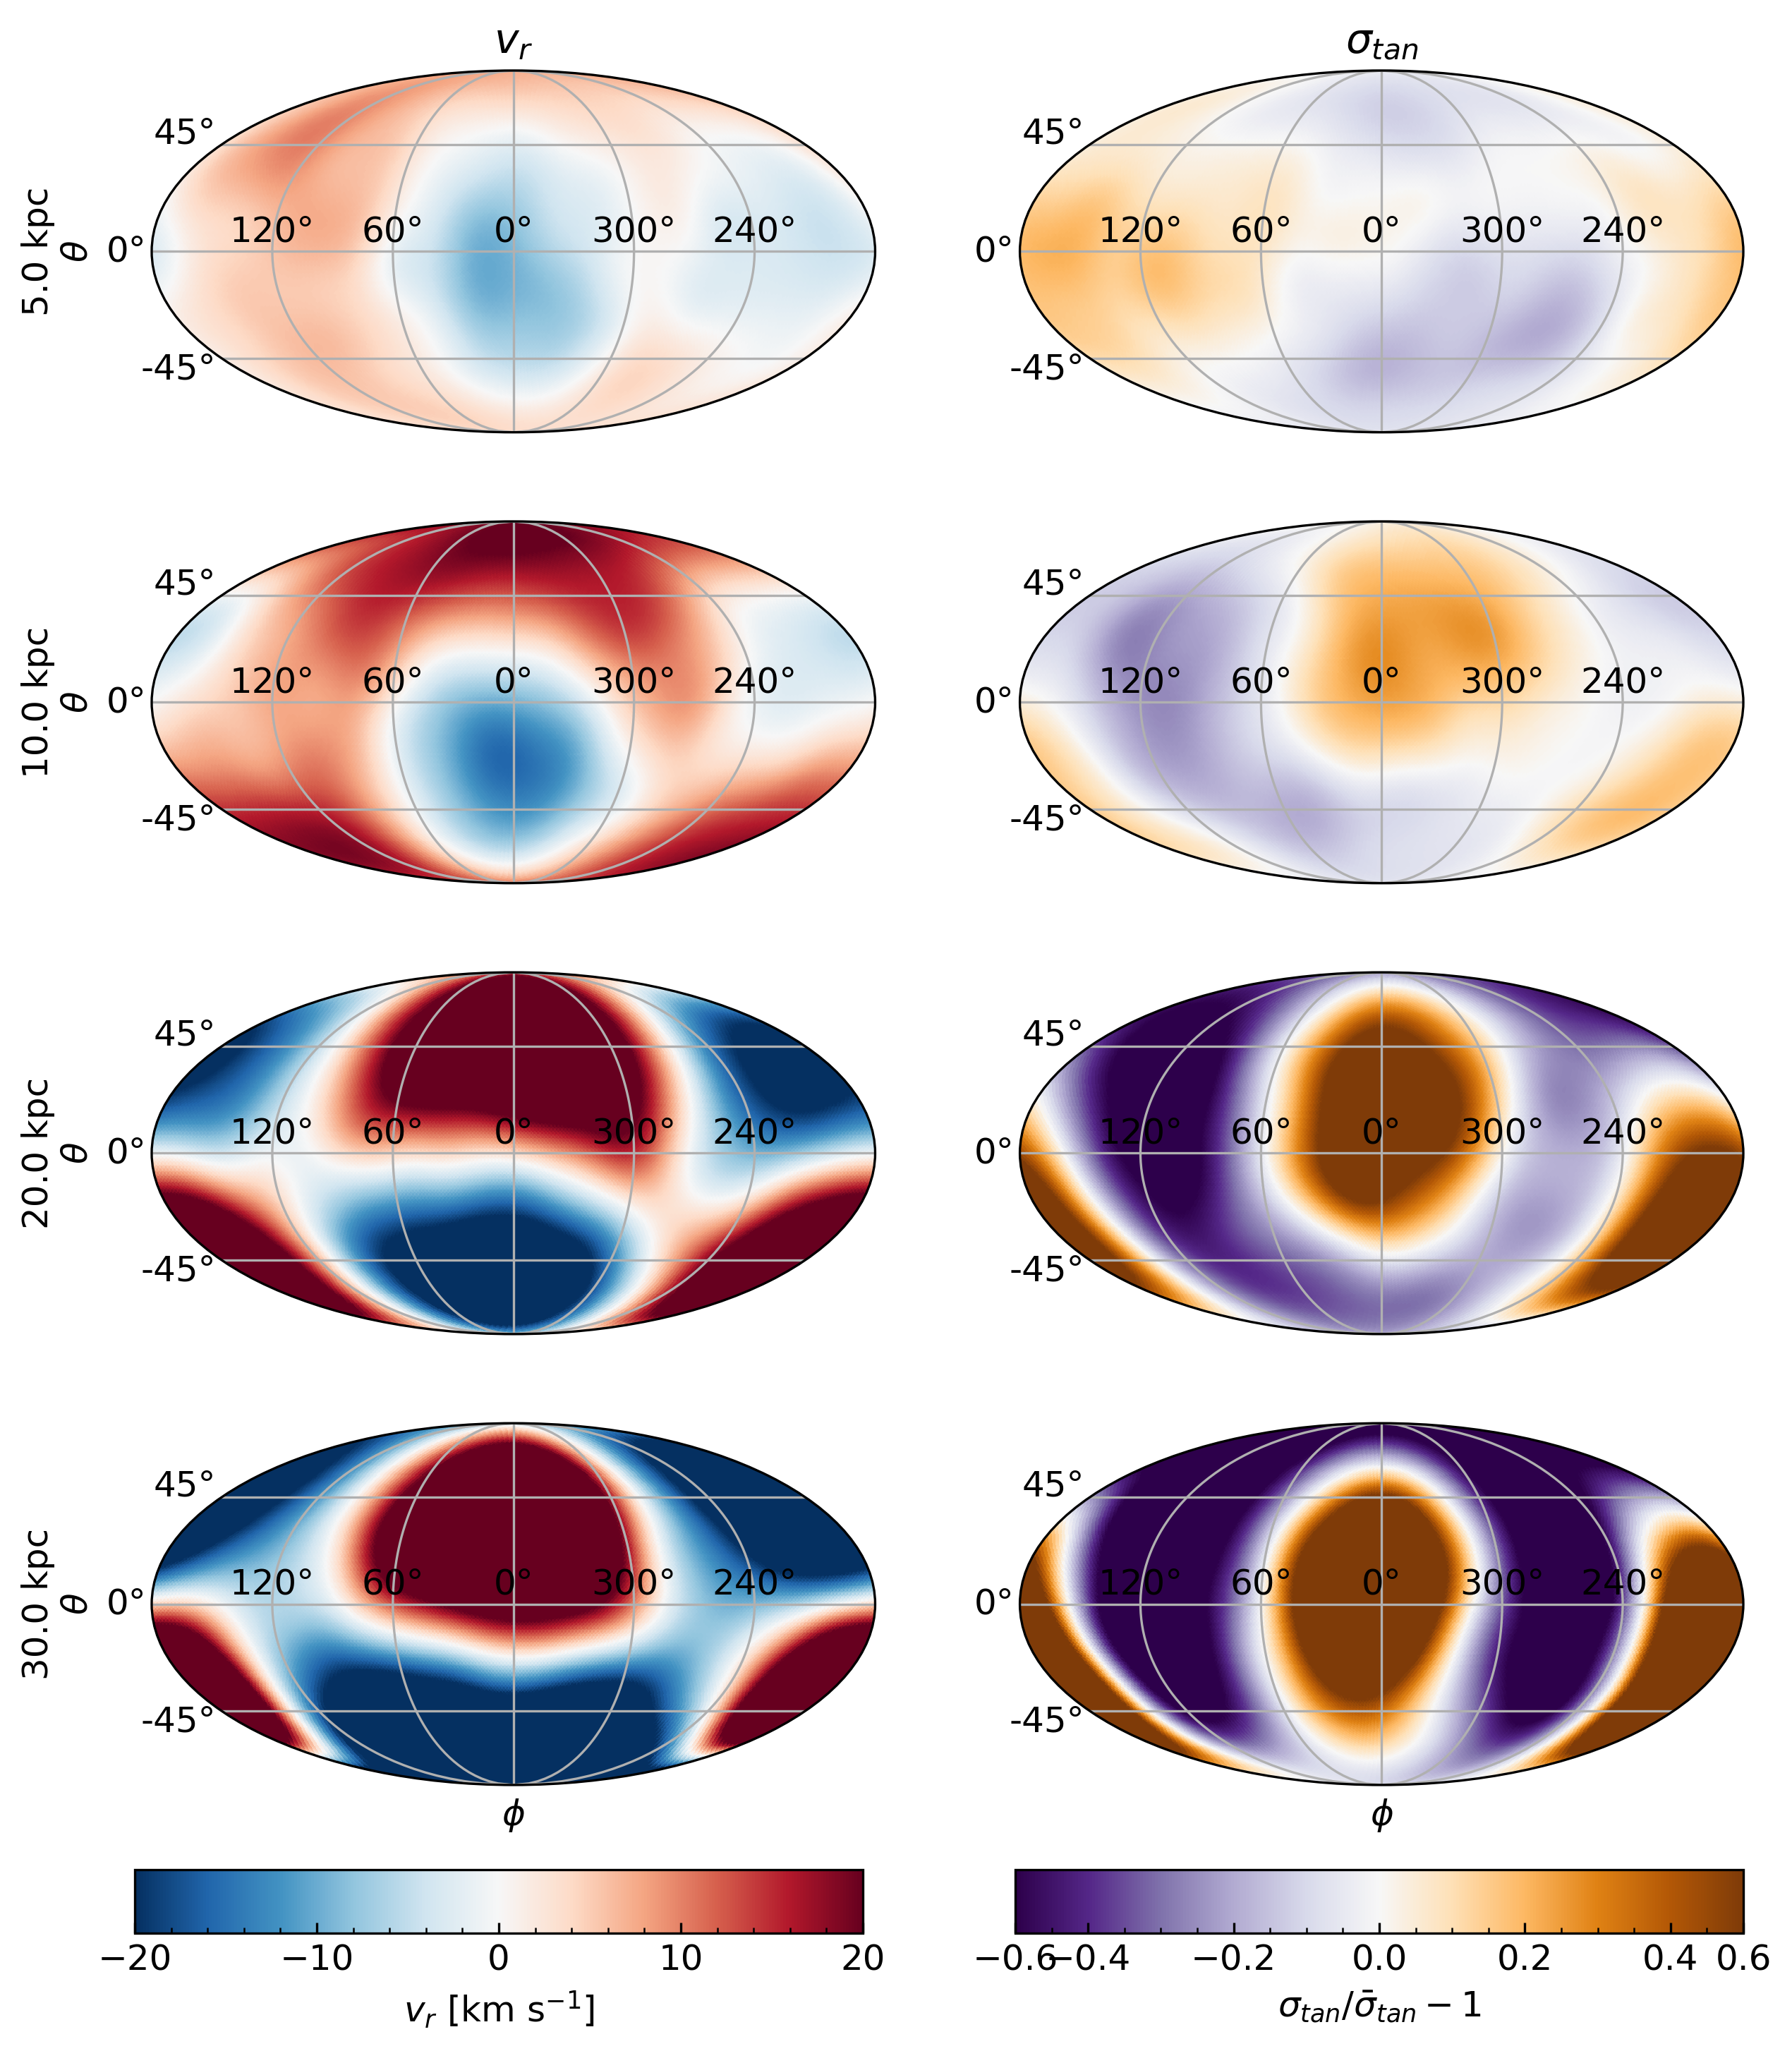

In [8]:
dm = snapshot(simdir+f"snap_{pres_idx}.hdf5", 1)
dm.read_all()

dm.select_particles((min_lmc_id, max_lmc_id))
dm.apply_center(lmc_c, lmc_v)
dm.apply_rotation(rot)

make_projections(dm, 'lmc_dm_rv_shells.png')

## SMC Stars

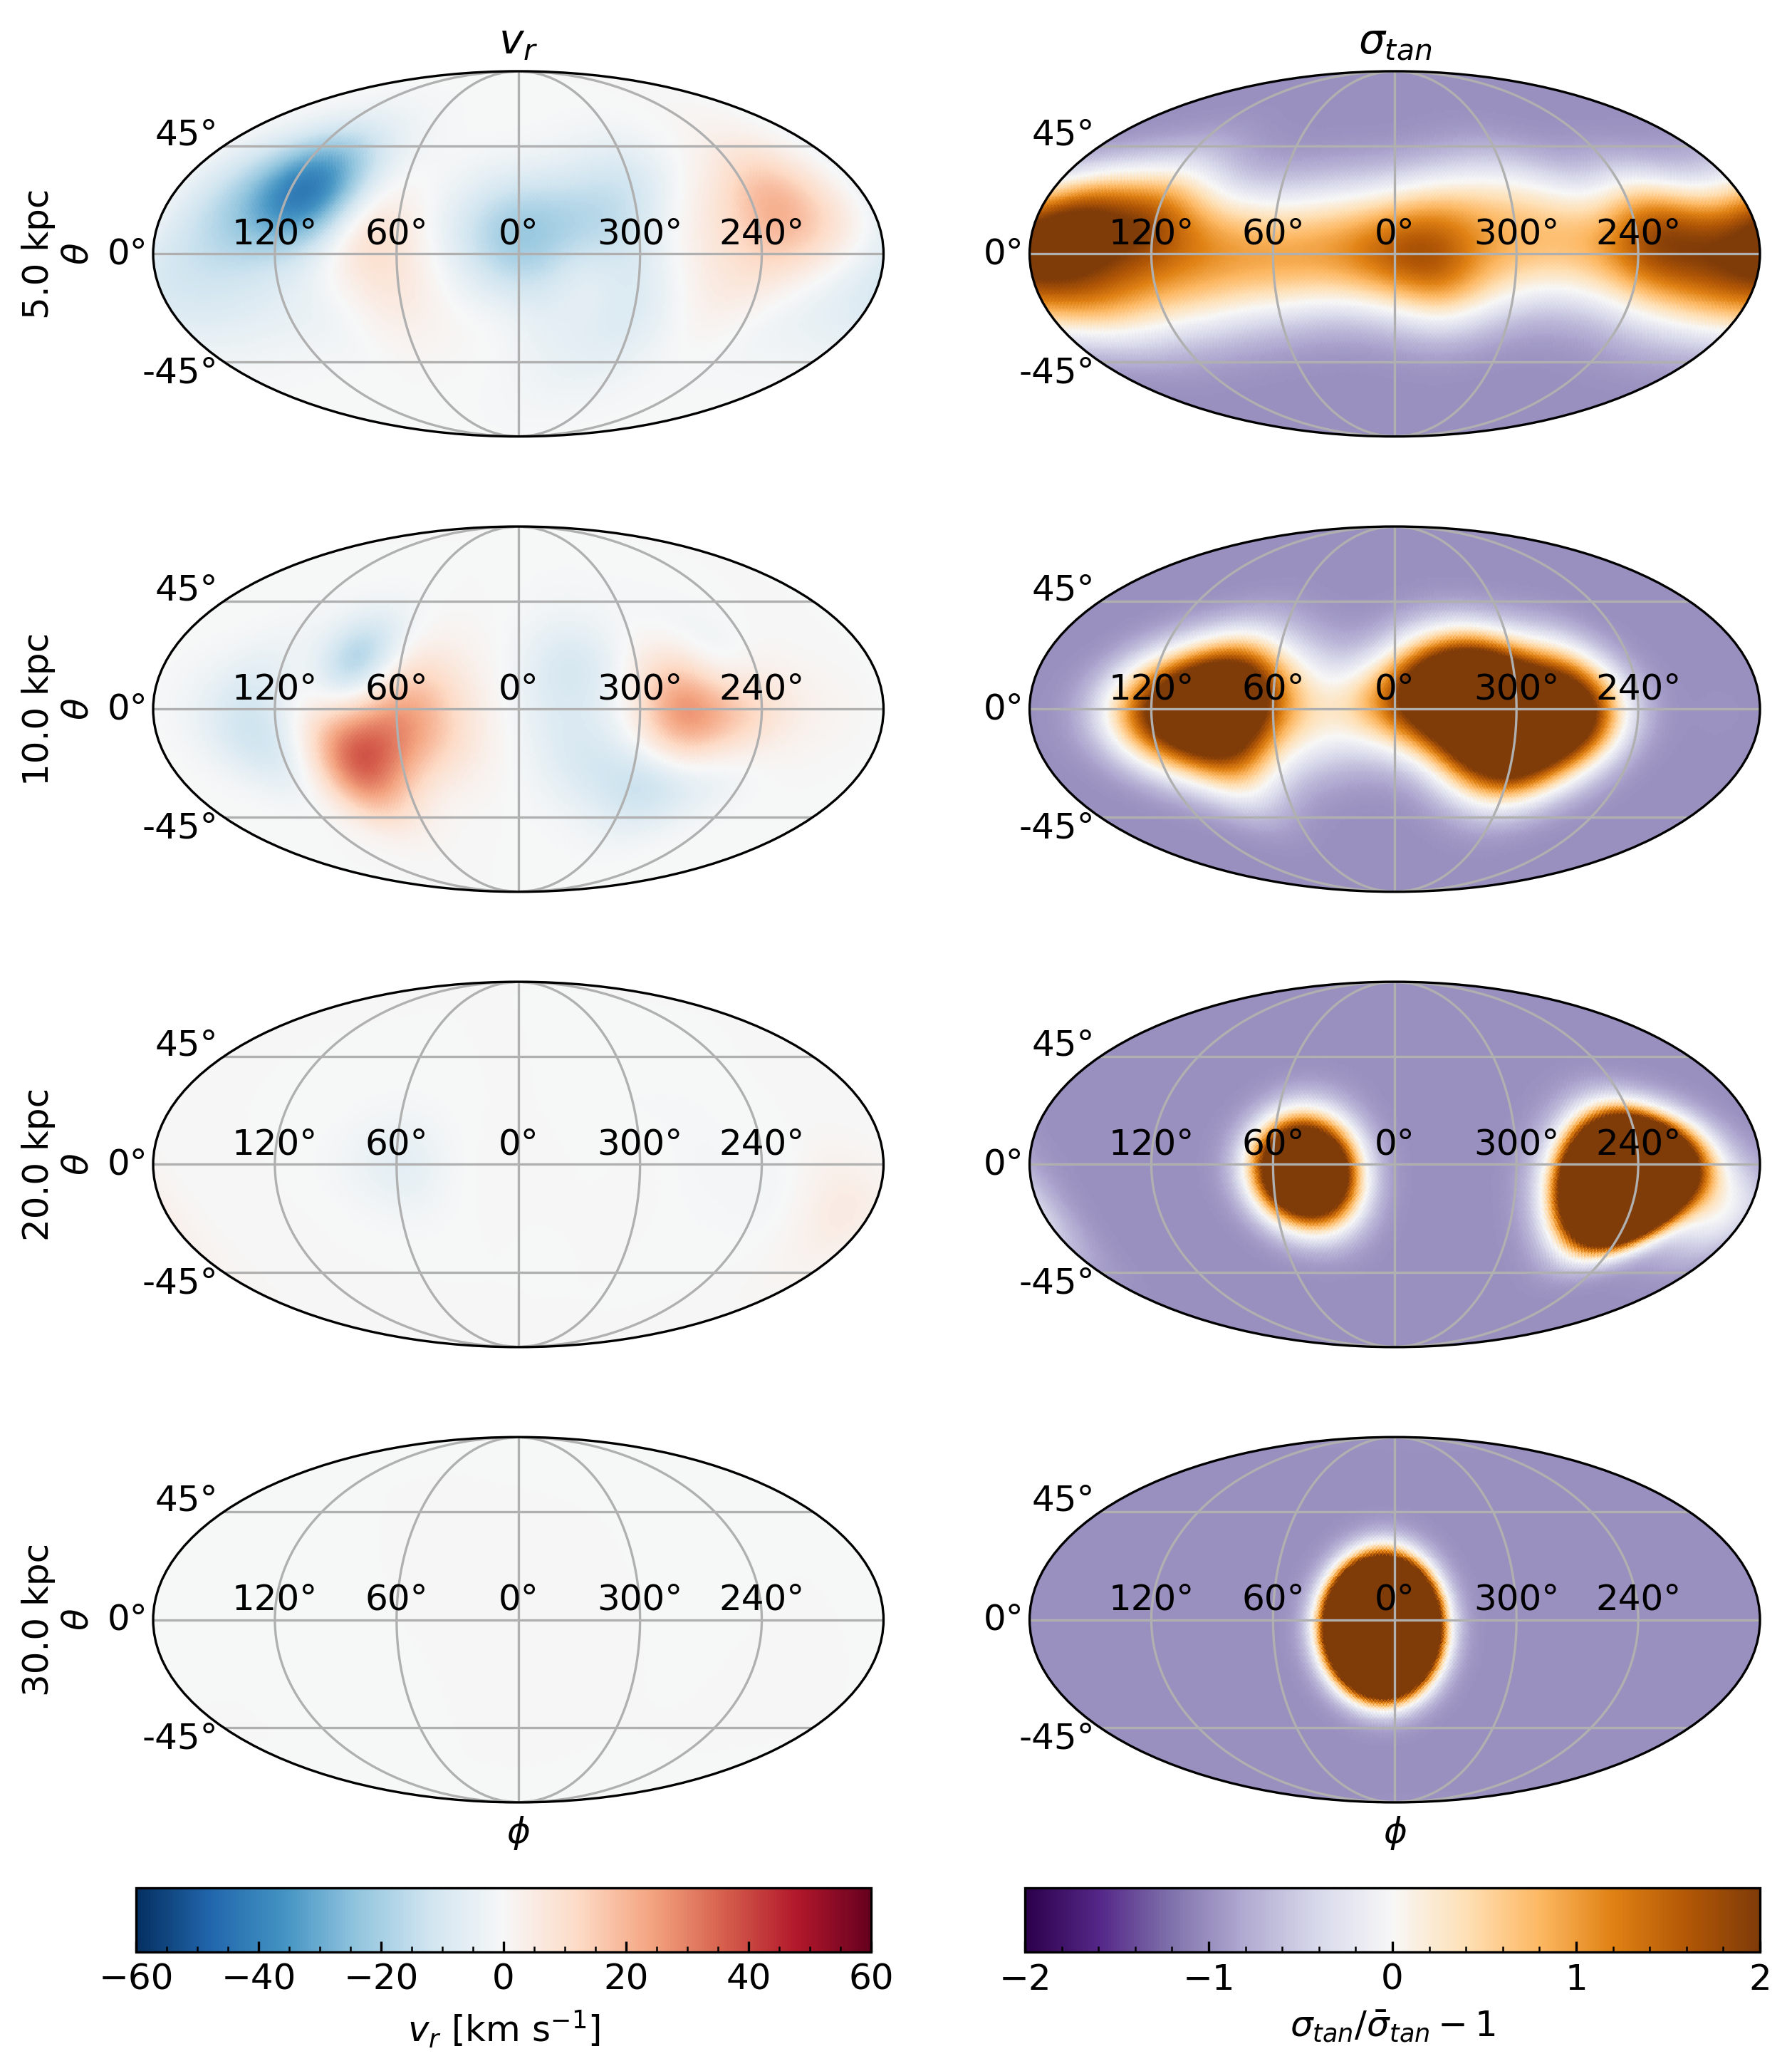

In [9]:
stars = snapshot(simdir+f"snap_{pres_idx}.hdf5", 2)
stars.read_all()
stars.select_particles((min_lmc_id, max_lmc_id))
stars.apply_center(lmc_c, lmc_v)
stars.apply_rotation(rot)

make_projections(stars, 'smc_stars_rv_shells.png', v_lim=60., sig_lim=2.)

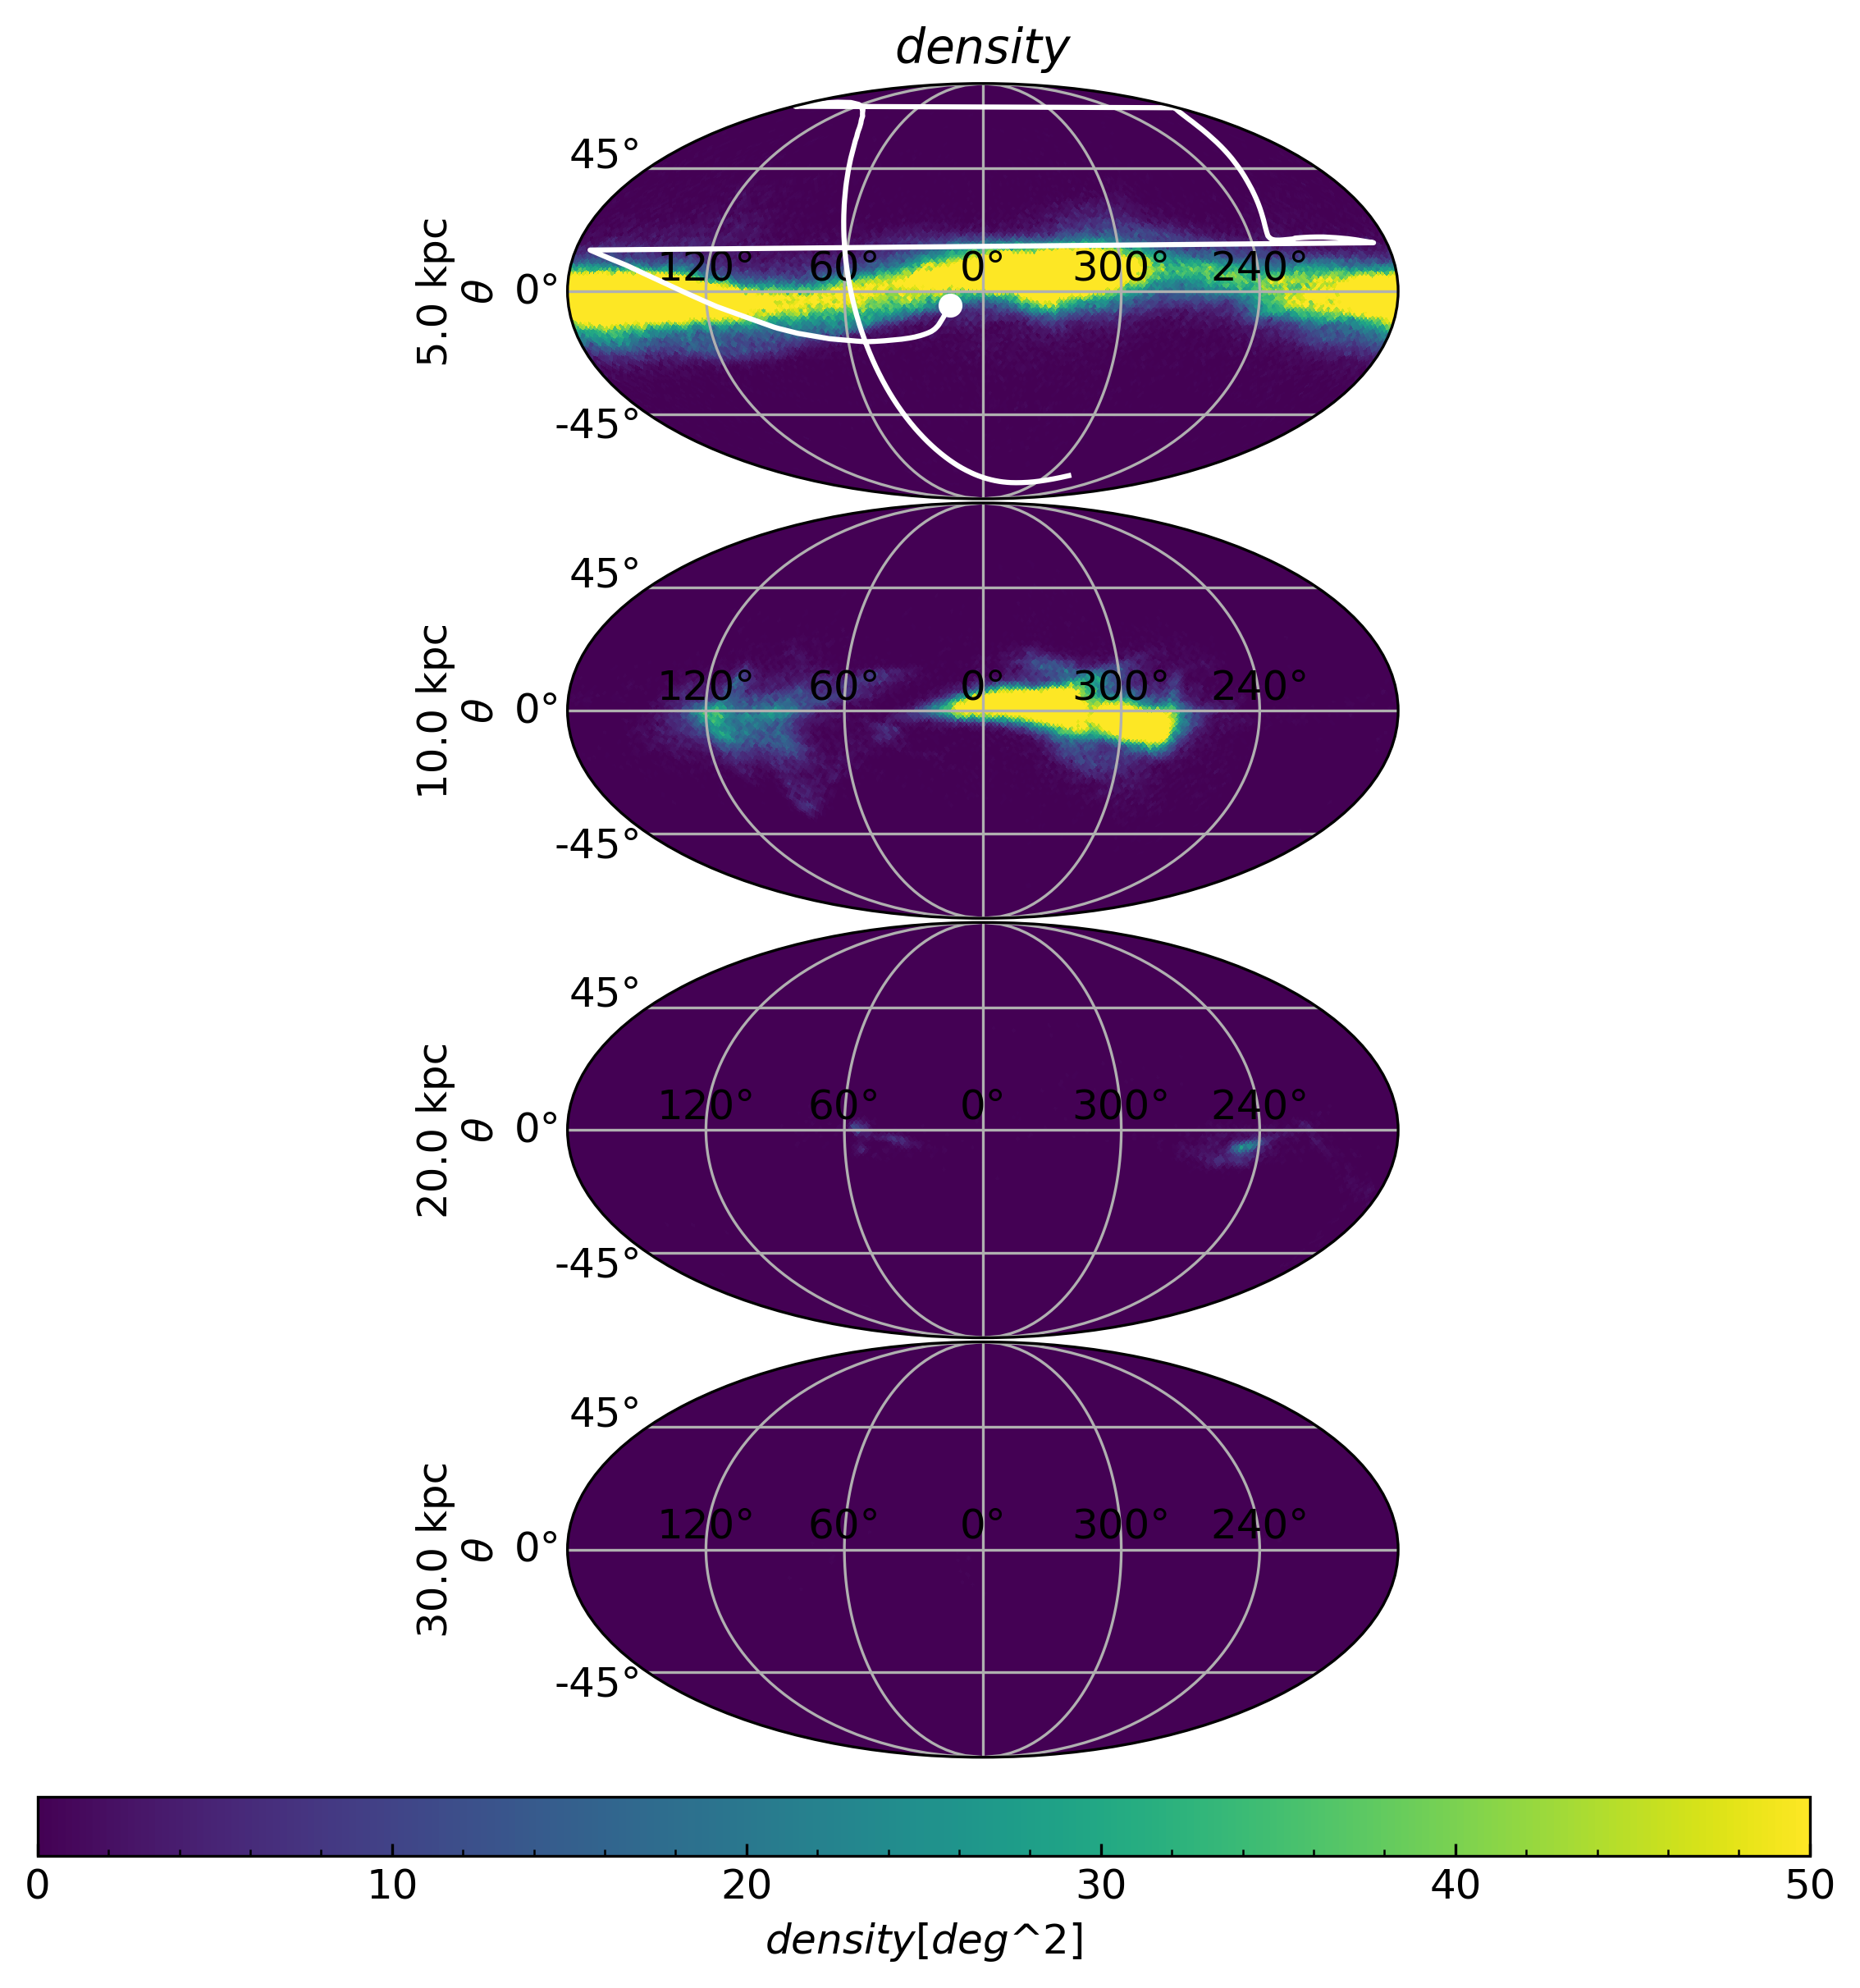

In [10]:
# density of SMC stars
make_density_maps(stars, 'smc_stars_shell_density.png', smooth=1.)

## Attempting to isolate MW tides

It's clear the majority of the radial velocity signature in the LMC halo is a quadrupole, due to MW tides. Let's try making the same plot with a simulation of the LMC-MW that does not include the SMC.

For this, we'll use the lmcmw04 MEGHA simulation, which is the same as the lmcsmcmw09 simulation, but without the SMC.

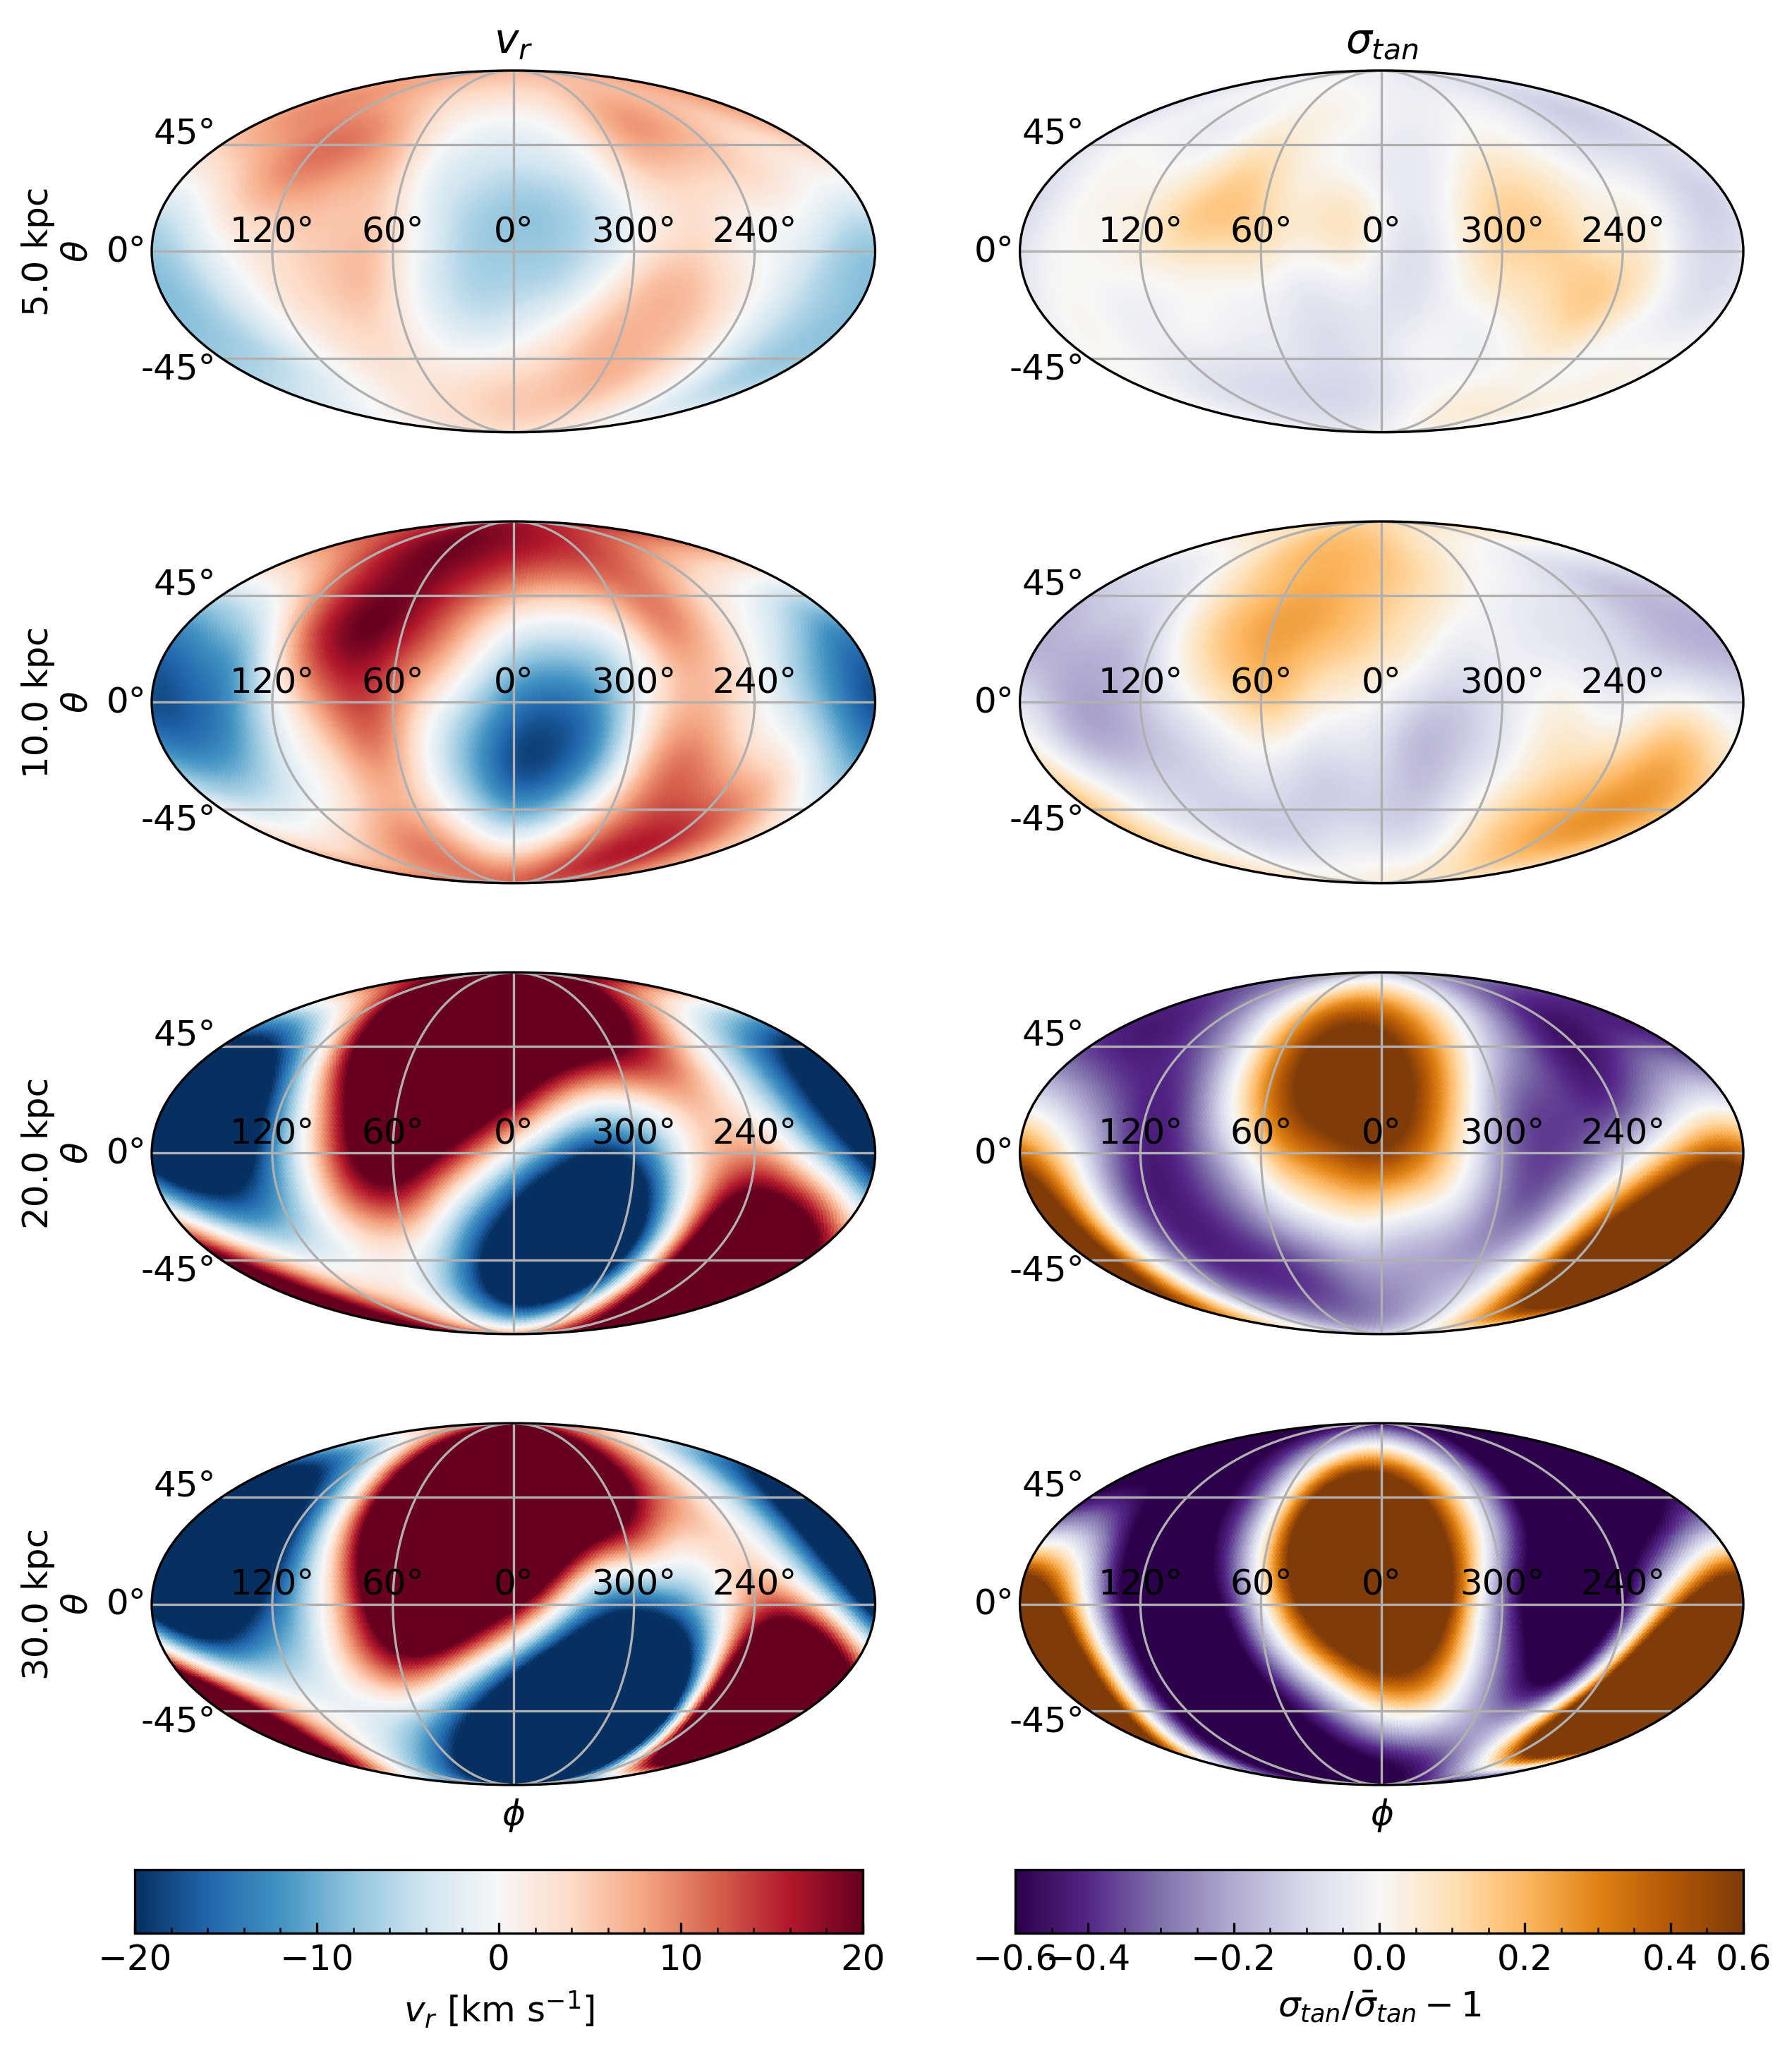

In [12]:
# I also have this snapshot stored on the UA HPC facilities
nosmc_simdir = '/xdisk/gbesla/group/lmcmw04/' # snapshots stored here
nosmc_comdir = '/xdisk/gbesla/group/lmcmw04/com/data/' # centers 
nosmc_rotdir = '/xdisk/gbesla/group/lmcmw04/angular_momentum/data/' # rotation matrices

# COMs
nosmc_lmc_c = np.load(nosmc_comdir+"LMC_com_pos.npy")[:,pres_idx]*u.kpc
nosmc_lmc_v = np.load(nosmc_comdir+"LMC_com_vel.npy")[:,pres_idx]*u.km/u.s
nosmc_mw_c = np.load(nosmc_comdir+"MW_com_pos.npy")[:,pres_idx]*u.kpc
nosmc_mw_v = np.load(nosmc_comdir+"MW_com_vel.npy")[:,pres_idx]*u.km/u.s

# Rotation to LMC disk plane
nosmc_rot = np.load(nosmc_rotdir+"LMC_align_matrix.npy")[:,:,pres_idx]

nosmc_snap = snapshot(nosmc_simdir+f"snap_{pres_idx}.hdf5", 1)
nosmc_snap.read_all()

nosmc_snap.select_particles((min_lmc_id, max_lmc_id))
nosmc_snap.apply_center(nosmc_lmc_c, nosmc_lmc_v)
nosmc_snap.apply_rotation(nosmc_rot)

make_projections(nosmc_snap, 'lmc_dm_rv_shells_nosmc.png')

## Observed frame (WIP)

Now, let's translate these kinematic maps to on-sky. We'll use astropy to translate the simulation box coordinates to Galactic coordinates, and make los velocity maps for different distance selections. For now, we'll assume no errors.

In [13]:
from astropy import coordinates as ac
from gala import coordinates as gc

In [14]:
# translate the LMC particles from both simulations to Galactic coordinates

with_smc = snapshot(simdir+f"snap_{pres_idx}.hdf5", 1)
with_smc.read_all()

with_smc.select_particles((min_lmc_id, max_lmc_id))
with_smc.apply_center(mw_c, mw_v)

lmc_dm_with_smc_galcen = ac.SkyCoord(
    x = with_smc.data_fields["Coordinates"][:,0],
    y = with_smc.data_fields["Coordinates"][:,1],
    z = with_smc.data_fields["Coordinates"][:,2],
    v_x = with_smc.data_fields["Velocities"][:,0],
    v_y = with_smc.data_fields["Velocities"][:,1],
    v_z = with_smc.data_fields["Velocities"][:,2],
    frame="galactocentric"
)
lmc_dm_with_smc_gal = lmc_dm_with_smc_galcen.transform_to(ac.Galactic)
lmc_dm_with_smc_gal_noreflex = gc.reflex_correct(lmc_dm_with_smc_gal)

In [15]:
without_smc = snapshot(nosmc_simdir+f"snap_{pres_idx}.hdf5", 1)
without_smc.read_all()

without_smc.select_particles((min_lmc_id, max_lmc_id))
without_smc.apply_center(nosmc_mw_c, nosmc_mw_v)

lmc_dm_without_smc_galcen = ac.SkyCoord(
    x = without_smc.data_fields["Coordinates"][:,0],
    y = without_smc.data_fields["Coordinates"][:,1],
    z = without_smc.data_fields["Coordinates"][:,2],
    v_x = without_smc.data_fields["Velocities"][:,0],
    v_y = without_smc.data_fields["Velocities"][:,1],
    v_z = without_smc.data_fields["Velocities"][:,2],
    frame="galactocentric"
)
lmc_dm_without_smc_gal = lmc_dm_without_smc_galcen.transform_to(ac.Galactic)
lmc_dm_without_smc_gal_noreflex = gc.reflex_correct(lmc_dm_without_smc_gal)

In [16]:
# plot radial velocity maps of LMC halo particles in 5 kpc shells 
# with SMC
lmc_dist = np.sqrt(np.sum((lmc_c - mw_c)**2))
mask = select_shell(lmc_dm_with_smc_gal_noreflex.distance.value, lmc_dist.value)

l = lmc_dm_with_smc_gal_noreflex.l.value[mask]
b = lmc_dm_with_smc_gal_noreflex.b.value[mask]
rv_with_smc = mollweide_projection((90-b)*np.pi/180., l*np.pi/180., "With SMC", q=lmc_dm_with_smc_gal_noreflex.radial_velocity.value[mask], stat='mean', returnMap=True, smooth=1.)
density_with_smc = mollweide_projection((90-b)*np.pi/180., l*np.pi/180., "With SMC", stat='mean', returnMap=True, smooth=1.)

In [23]:
# without SMC
lmc_dist = np.sqrt(np.sum((nosmc_lmc_c - nosmc_mw_c)**2))
mask = select_shell(lmc_dm_without_smc_gal_noreflex.distance.value, lmc_dist.value)

l = lmc_dm_without_smc_gal_noreflex.l.value[mask]
b = lmc_dm_without_smc_gal_noreflex.b.value[mask]
rv_without_smc = mollweide_projection((90-b)*np.pi/180., l*np.pi/180., "Without SMC", q=lmc_dm_without_smc_gal_noreflex.radial_velocity.value[mask], stat='mean', returnMap=True, smooth=1.)
density_without_smc = mollweide_projection((90-b)*np.pi/180., l*np.pi/180., "Without SMC", stat='mean', returnMap=True, smooth=1.)

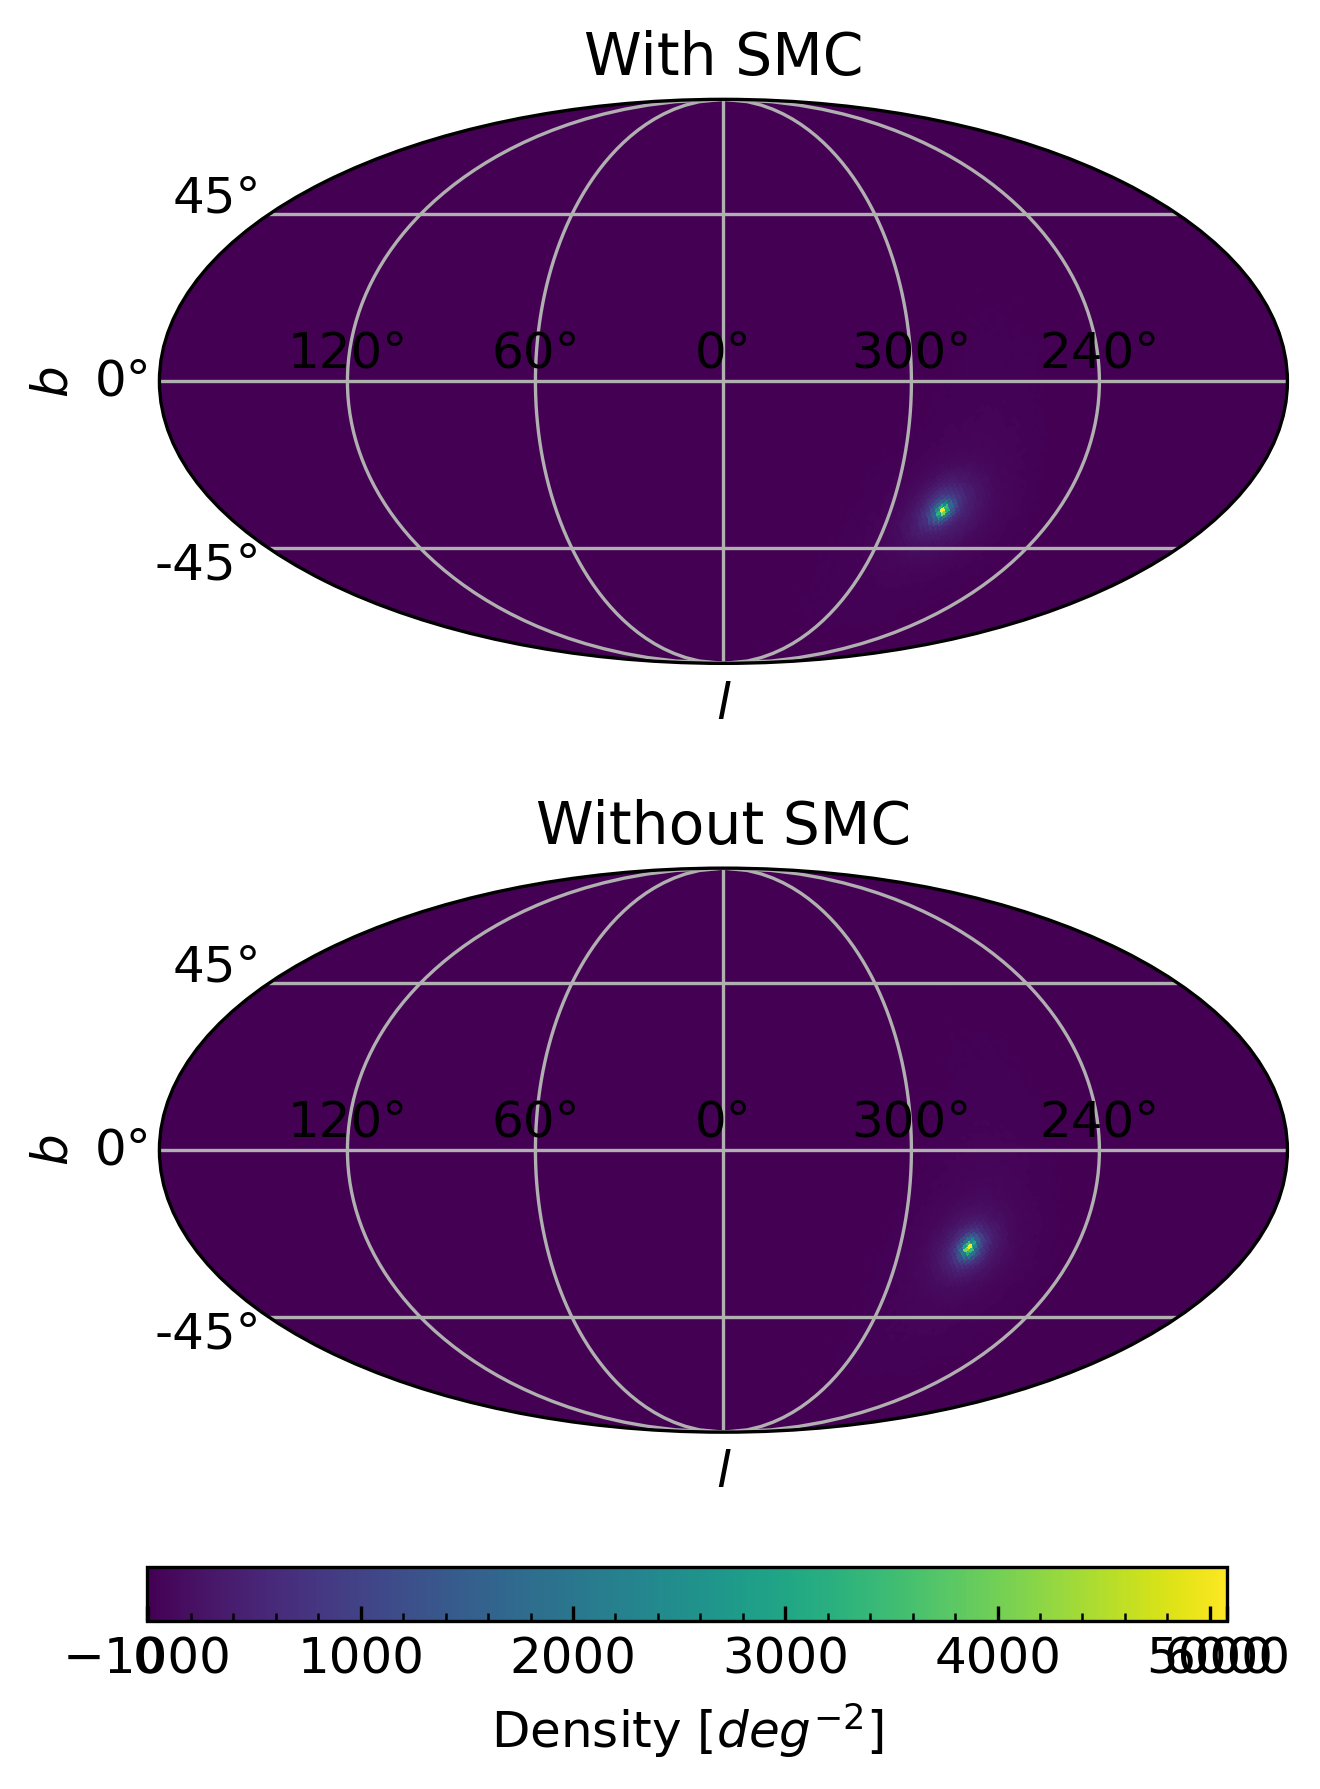

In [28]:
plt.rcParams['font.size'] = '12'
fig, axes = plt.subplots(2, 1, figsize=(4, 6), dpi=300)

cmap_vr = 'RdBu_r'

plt.axes(axes[0])
hp.newvisufunc.projview(
    density_with_smc,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    rot=(0, 0, 0),
    xlabel="$l$",
    ylabel="$b$",
    min=None,
    max=None,
    cmap="viridis",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title='With SMC',
    sub=211,
    cbar=False,
    hold=True
    )

plt.axes(axes[1])
im1 = hp.newvisufunc.projview(
    density_without_smc,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    rot=(0, 0, 0),
    xlabel="$l$",
    ylabel="$b$",
    min=None,
    max=None,
    cmap="viridis",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title='Without SMC',
    sub=212,
    cbar=False,
    hold=True
    )

plt.subplots_adjust(bottom=0.1, hspace=0.01)
cbar1_ax = fig.add_axes([0.03, 0.05, 0.9, 0.03])
plt.colorbar(im1, cax=cbar1_ax, label='Density $[deg^{-2}]$', orientation='horizontal')
# plt.legend()
plt.savefig("galactic_projections_density.png", bbox_inches='tight')
plt.show()

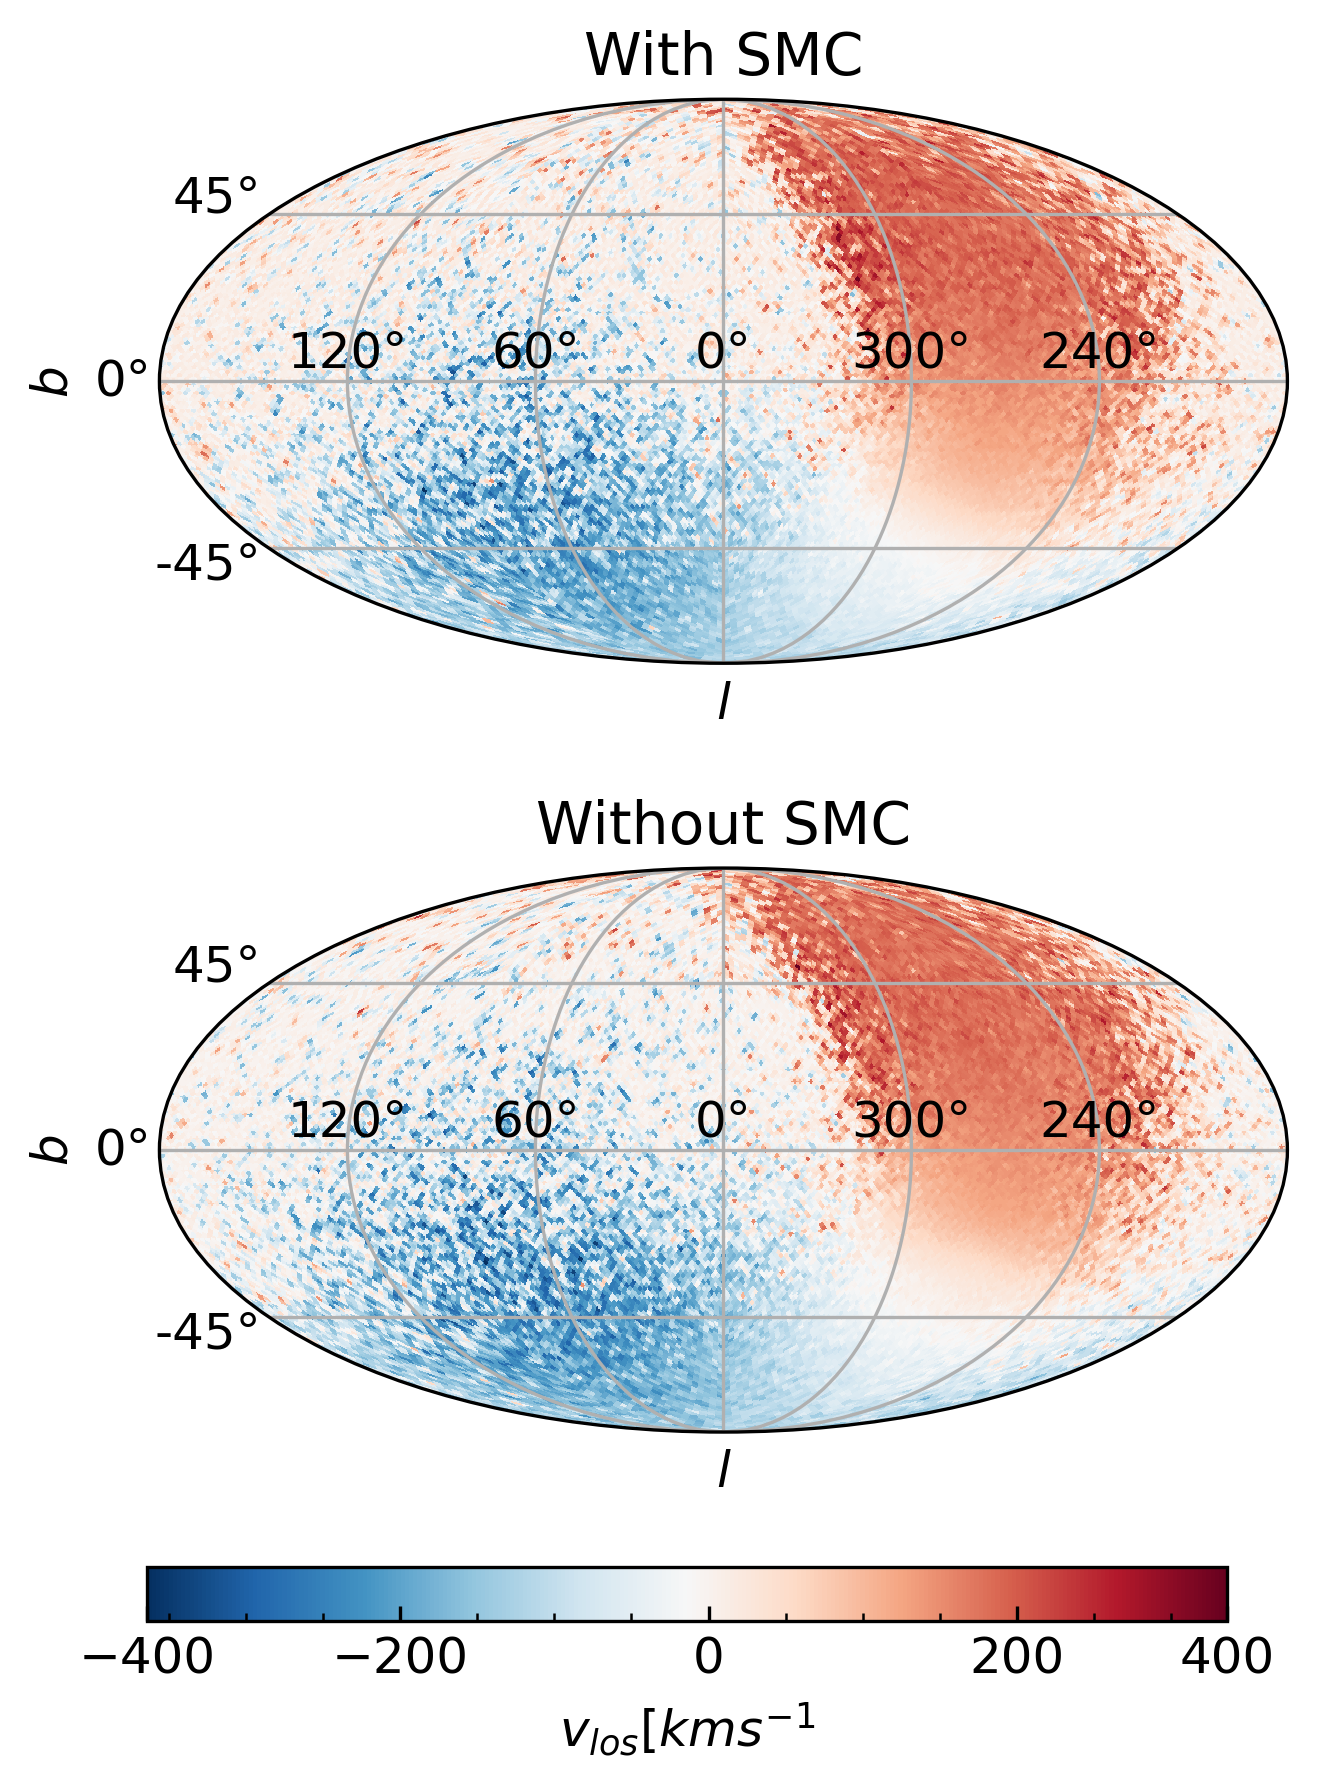

In [29]:
plt.rcParams['font.size'] = '12'
fig, axes = plt.subplots(2, 1, figsize=(4, 6), dpi=300)

cmap_vr = 'RdBu_r'

plt.axes(axes[0])
hp.newvisufunc.projview(
    rv_with_smc,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    rot=(0, 0, 0),
    xlabel="$l$",
    ylabel="$b$",
    min=None,
    max=None,
    cmap=cmap_vr,
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title='With SMC',
    sub=211,
    cbar=False,
    hold=True
    )

plt.axes(axes[1])
im1 = hp.newvisufunc.projview(
    rv_without_smc,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    rot=(0, 0, 0),
    xlabel="$l$",
    ylabel="$b$",
    min=None,
    max=None,
    cmap=cmap_vr,
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title='Without SMC',
    sub=212,
    cbar=False,
    hold=True
    )

plt.subplots_adjust(bottom=0.1, hspace=0.01)
cbar1_ax = fig.add_axes([0.03, 0.05, 0.9, 0.03])
plt.colorbar(im1, cax=cbar1_ax, label='$v_{los} [km s^{-1}$', orientation='horizontal')
# plt.legend()
plt.savefig("galactic_projections_velocity.png", bbox_inches='tight')
plt.show()